## Module 5: Analyse, diagnose and improve a model​

In the excercise of this week you will be working with financial data in order to (hopefully) find a portfolio of equities which outperform SP500. The data that you are gonna work with has two main sources: 
* Financial data from the companies extracted from the quarterly company reports (mostly extracted from [macrotrends](https://www.macrotrends.net/) so you can use this website to understand better the data and get insights on the features, for example [this](https://www.macrotrends.net/stocks/charts/AAPL/apple/revenue) is the one corresponding to APPLE)
* Stock prices, mostly extracted from [morningstar](https://indexes.morningstar.com/page/morningstar-indexes-empowering-investor-success?utm_source=google&utm_medium=cpc&utm_campaign=MORNI%3AG%3ASearch%3ABrand%3ACore%3AUK%20MORNI%3ABrand%3ACore%3ABroad&utm_content=engine%3Agoogle%7Ccampaignid%3A18471962329%7Cadid%3A625249340069&utm_term=morningstar%20index&gclid=CjwKCAjws9ipBhB1EiwAccEi1Fu6i20XHVcxFxuSEtJGF0If-kq5-uKnZ3rov3eRkXXFfI5j8QBtBBoCayEQAvD_BwE), which basically tell us how the stock price is evolving so we can use it both as past features and the target to predict).

Before going to the problem that we want to solve, let's comment some of the columns of the dataset:


* `Ticker`: a [short name](https://en.wikipedia.org/wiki/Ticker_symbol) to identify the equity (that you can use to search in macrotrends)
* `date`: the date of the company report (normally we are gonna have 1 every quarter). This is for informative purposes but you can ignore it when modeling.
* `execution date`: the date when we would had executed the algorithm for that equity. We want to execute the algorithm once per quarter to create the portfolio, but the release `date`s of all the different company reports don't always match for the quarter, so we just take a common `execution_date` for all of them.
* `stock_change_div_365`: what is the % change of the stock price (with dividens) in the FOLLOWING year after `execution date`. 
* `sp500_change_365`: what is the % change of the SP500 in the FOLLOWING year after `execution date`.
* `close_0`: what is the price at the moment of `execution date`
* `stock_change__minus_120` what is the % change of the stock price in the last 120 days
* `stock_change__minus_730`: what is the % change of the stock price in the last 730 days

The rest of the features can be divided beteween financial features (the ones coming from the reports) and technical features (coming from the stock price). We leave the technical features here as a reference: 

In [39]:
technical_features = ['close_0', 'close_sp500_0', 'close_365', 'close_sp500_365',
       'close__minus_120', 'close_sp500__minus_120', 'close__minus_365',
       'close_sp500__minus_365', 'close__minus_730', 'close_sp500__minus_730',
       'stock_change_365','stock_change_div_365', 'sp500_change_365', 'stock_change__minus_120',
       'sp500_change__minus_120', 'stock_change__minus_365',
       'sp500_change__minus_365', 'stock_change__minus_730','sp500_change__minus_730',
       'std__minus_365','std__minus_730','std__minus_120']


The problem that we want to solve is basically find a portfolio of `top_n` tickers (initially set to 10) to invest every `execution date` (basically once per quarter) and the goal is to have a better return than `SP500` in the following year. The initial way to model this is to have a binary target which is 1 when `stock_change_div_365` - `sp500_change_365` (the difference between the return of the equity and the SP500 in the following year) is positive or 0 otherwise. So we try to predict the probability of an equity of improving SP500 in the following year, we take the `top_n` equities and compute their final return.

In [40]:
import pandas as pd
import re
import numpy as np
import lightgbm as lgb
from plotnine import ggplot, geom_histogram, aes, geom_col, coord_flip,geom_bar,scale_x_discrete, geom_point, theme,element_text


In [41]:
# number of trees in lightgbm
n_trees = 40
minimum_number_of_tickers = 1500
# Number of the quarters in the past to train
n_train_quarters = 36
# number of tickers to make the portfolio
top_n = 10


> **Changed:** using relative path so the notebook runs from any machine.

In [42]:
data_set = pd.read_feather("financials_against_return.feather")


Remove these quarters which have les than `minimum_number_of_tickers` tickers:

In [43]:
df_quarter_lengths = data_set.groupby(["execution_date"]).size().reset_index().rename(columns = {0:"count"})
data_set = pd.merge(data_set, df_quarter_lengths, on = ["execution_date"])
data_set = data_set[data_set["count"]>=minimum_number_of_tickers]


In [44]:
data_set.shape


(170483, 145)

Create the target:

In [45]:
data_set["diff_ch_sp500"] = data_set["stock_change_div_365"] - data_set["sp500_change_365"]

data_set.loc[data_set["diff_ch_sp500"]>0,"target"] = 1
data_set.loc[data_set["diff_ch_sp500"]<0,"target"] = 0

data_set["target"].value_counts()


target
0.0    82437
1.0    73829
Name: count, dtype: int64

This function computes the main metric that we want to optimize: given a prediction where we have probabilities for each equity, we sort the equities in descending order of probability, we pick the `top_n` ones, and we we weight the returned `diff_ch_sp500` by the probability:

In [46]:
def get_weighted_performance_of_stocks(df,metric):
    df["norm_prob"] = 1/len(df)
    return np.sum(df["norm_prob"]*df[metric])

def get_top_tickers_per_prob(preds):
    if len(preds) == len(train_set):
        data_set = train_set.copy()
    elif len(preds) == len(test_set):
        data_set = test_set.copy()
    else:
        assert ("Not matching train/test")
    data_set["prob"] = preds
    data_set = data_set.sort_values(["prob"], ascending = False)
    data_set = data_set.head(top_n)
    return data_set

# main metric to evaluate: average diff_ch_sp500 of the top_n stocks
def top_wt_performance(preds, train_data):
    top_dataset = get_top_tickers_per_prob(preds)
    return "weighted-return", get_weighted_performance_of_stocks(top_dataset,"diff_ch_sp500"), True


We have created for you a function to make the `train` and `test` split based on a `execution_date`:

In [47]:
def split_train_test_by_period(data_set, test_execution_date,include_nulls_in_test = False):
    # we train with everything happening at least one year before the test execution date
    train_set = data_set.loc[data_set["execution_date"] <= pd.to_datetime(test_execution_date) - pd.Timedelta(350, unit = "day")]
    # remove those rows where the target is null
    train_set = train_set[~pd.isna(train_set["diff_ch_sp500"])]
    execution_dates = train_set.sort_values("execution_date")["execution_date"].unique()
    # Pick only the last n_train_quarters
    if n_train_quarters!=None:
        train_set = train_set[train_set["execution_date"].isin(execution_dates[-n_train_quarters:])]
        
    # the test set are the rows happening in the execution date with the concrete frequency
    test_set = data_set.loc[(data_set["execution_date"] == test_execution_date)]
    if not include_nulls_in_test:
        test_set = test_set[~pd.isna(test_set["diff_ch_sp500"])]
    test_set = test_set.sort_values('date', ascending = False).drop_duplicates('Ticker', keep = 'first')
    
    return train_set, test_set


Ensure that we don't include features which are irrelevant or related to the target:

> **Changed:** added `sp500_change_730` (forward-looking 2-year SP500 return, was missing) and removed duplicate `sp500_change_365` entry — see Step 1.

In [48]:
def get_columns_to_remove():
    columns_to_remove = [
                         "date",
                         "improve_sp500",
                         "Ticker",
                         "freq",
                         "set",
                         "close_sp500_365",
                         "close_365",
                         "stock_change_365",
                         "sp500_change_365",
                         "stock_change_div_365",
                         "stock_change_730",
                         "stock_change_div_730",
                         "sp500_change_730",
                         "diff_ch_sp500",
                         "diff_ch_avg_500",
                         "execution_date","target","index","quarter","std_730","count"]
        
    return columns_to_remove


This is the main modeling function, it receives a train test and a test set and trains a `lightgbm` in classification mode. We don't recommend to change the main algorithm for this excercise but we suggest to play with its hyperparameters:

In [49]:
import warnings
warnings.filterwarnings('ignore')


def train_model(train_set,test_set,n_estimators = 300):

    columns_to_remove = get_columns_to_remove()
    
    X_train = train_set.drop(columns = columns_to_remove, errors = "ignore")
    X_test = test_set.drop(columns = columns_to_remove, errors = "ignore")
    
    
    y_train = train_set["target"]
    y_test = test_set["target"]

    lgb_train = lgb.Dataset(X_train,y_train)
    lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)
    
    eval_result = {}
    
 
    objective = 'binary'
    metric = 'binary_logloss' 
    params = {
             "random_state":1, 
             "verbosity": -1,
             "n_jobs":10, 
             "n_estimators":n_estimators,
             "objective": objective,
             "metric": metric}
    
    model = lgb.train(params = params,train_set = lgb_train,
                      valid_sets = [lgb_test,lgb_train],
                      feval = [top_wt_performance],
                      callbacks = [lgb.record_evaluation(eval_result = eval_result)])
    return model,eval_result,X_train,X_test


This is the function which receives an `execution_date` and splits the dataset between train and test, trains the models and evaluates the model in test. It returns a dictionary with the different evaluation metrics in train and test:

In [50]:
def run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_estimators,include_nulls_in_test = False):
        global train_set
        global test_set
        # split the dataset between train and test
        train_set, test_set = split_train_test_by_period(data_set,execution_date,include_nulls_in_test = include_nulls_in_test)
        train_size, _ = train_set.shape
        test_size, _ = test_set.shape
        model = None
        X_train = None
        X_test = None
        
        # if both train and test are not empty
        if train_size > 0 and test_size>0:
            model, evals_result, X_train, X_test = train_model(train_set,
                                                              test_set,
                                                              n_estimators = n_estimators)
            
            test_set['prob'] = model.predict(X_test)
            predicted_tickers = test_set.sort_values('prob', ascending = False)
            predicted_tickers["execution_date"] = execution_date
            all_results[(execution_date)] = evals_result
            all_models[(execution_date)] = model
            all_predicted_tickers_list.append(predicted_tickers)
        return all_results,all_predicted_tickers_list,all_models,model,X_train,X_test


execution_dates = np.sort( data_set['execution_date'].unique() )


This is the main training loop: it goes through each different `execution_date` and calls `run_model_for_execution_date`. All the results are stored in `all_results` and the predictions in `all_predicted_tickers_list`.

In [51]:
all_results = {}
all_predicted_tickers_list = []
all_models = {}

for execution_date in execution_dates:
    print(execution_date)
    all_results,all_predicted_tickers_list,all_models,model,X_train,X_test = run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_trees,False)
all_predicted_tickers = pd.concat(all_predicted_tickers_list) 


2005-06-30T00:00:00.000000000
2005-09-30T00:00:00.000000000
2005-12-30T00:00:00.000000000
2006-03-31T00:00:00.000000000
2006-06-30T00:00:00.000000000
2006-09-30T00:00:00.000000000
2006-12-30T00:00:00.000000000
2007-03-31T00:00:00.000000000
2007-06-30T00:00:00.000000000
2007-09-30T00:00:00.000000000
2007-12-30T00:00:00.000000000
2008-03-31T00:00:00.000000000
2008-06-30T00:00:00.000000000
2008-09-30T00:00:00.000000000
2008-12-30T00:00:00.000000000
2009-03-31T00:00:00.000000000
2009-06-30T00:00:00.000000000
2009-09-30T00:00:00.000000000
2009-12-30T00:00:00.000000000
2010-03-31T00:00:00.000000000
2010-06-30T00:00:00.000000000
2010-09-30T00:00:00.000000000
2010-12-30T00:00:00.000000000
2011-03-31T00:00:00.000000000
2011-06-30T00:00:00.000000000
2011-09-30T00:00:00.000000000
2011-12-30T00:00:00.000000000
2012-03-31T00:00:00.000000000
2012-06-30T00:00:00.000000000
2012-09-30T00:00:00.000000000
2012-12-30T00:00:00.000000000
2013-03-31T00:00:00.000000000
2013-06-30T00:00:00.000000000
2013-09-30

In [52]:
def parse_results_into_df(set_):
    df = pd.DataFrame()
    for date in all_results:
        df_tmp = pd.DataFrame(all_results[(date)][set_])
        df_tmp["n_trees"] = list(range(len(df_tmp)))
        df_tmp["execution_date"] = date
        df= pd.concat([df,df_tmp])
    
    df["execution_date"] = df["execution_date"].astype(str)
    
    return df


In [53]:
test_results = parse_results_into_df("valid_0")
train_results = parse_results_into_df("training")


In [54]:
test_results_final_tree = test_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")
train_results_final_tree = train_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")


And this are the results:

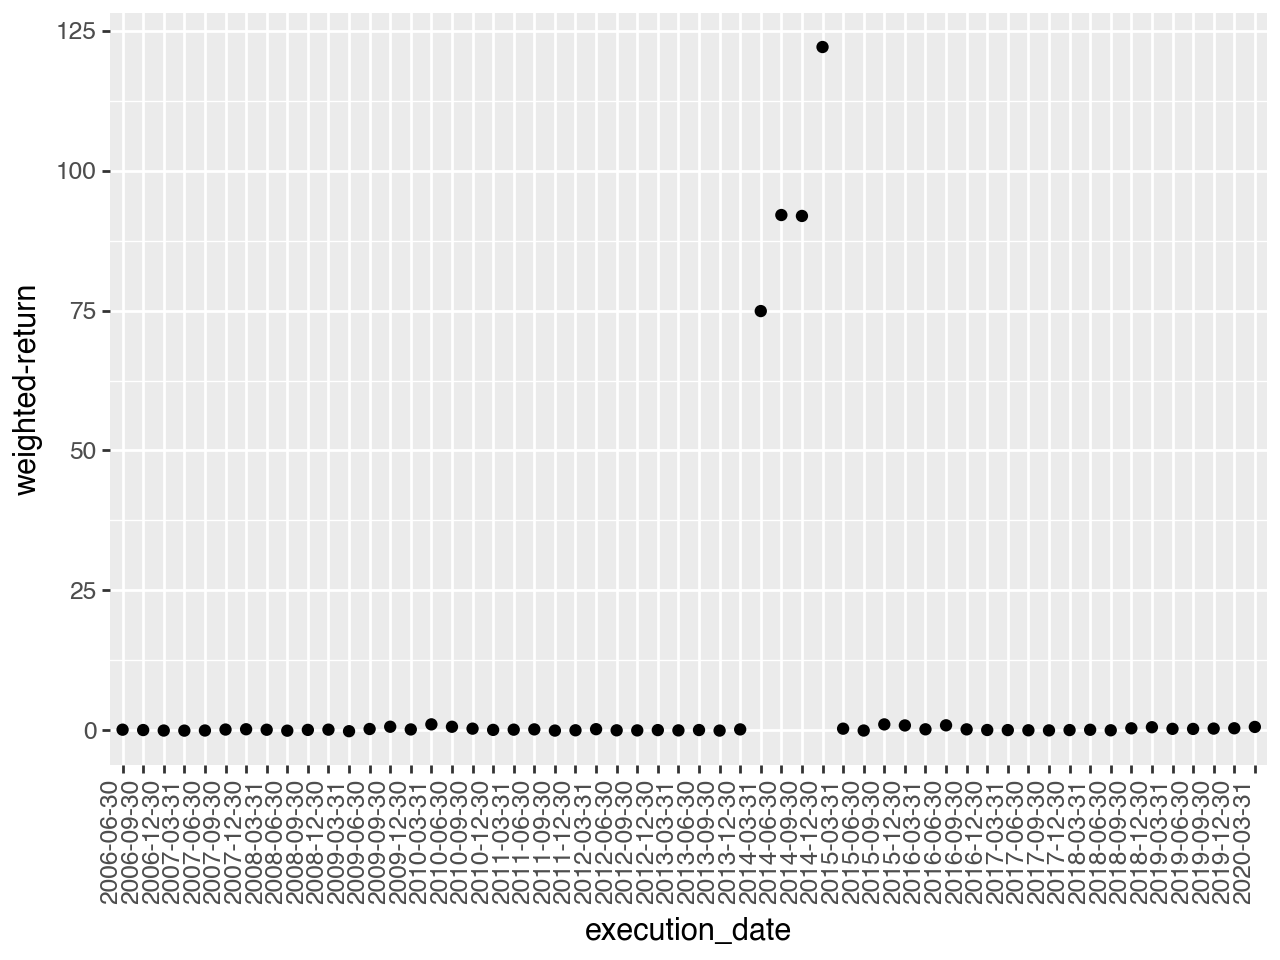

In [55]:
ggplot(test_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))


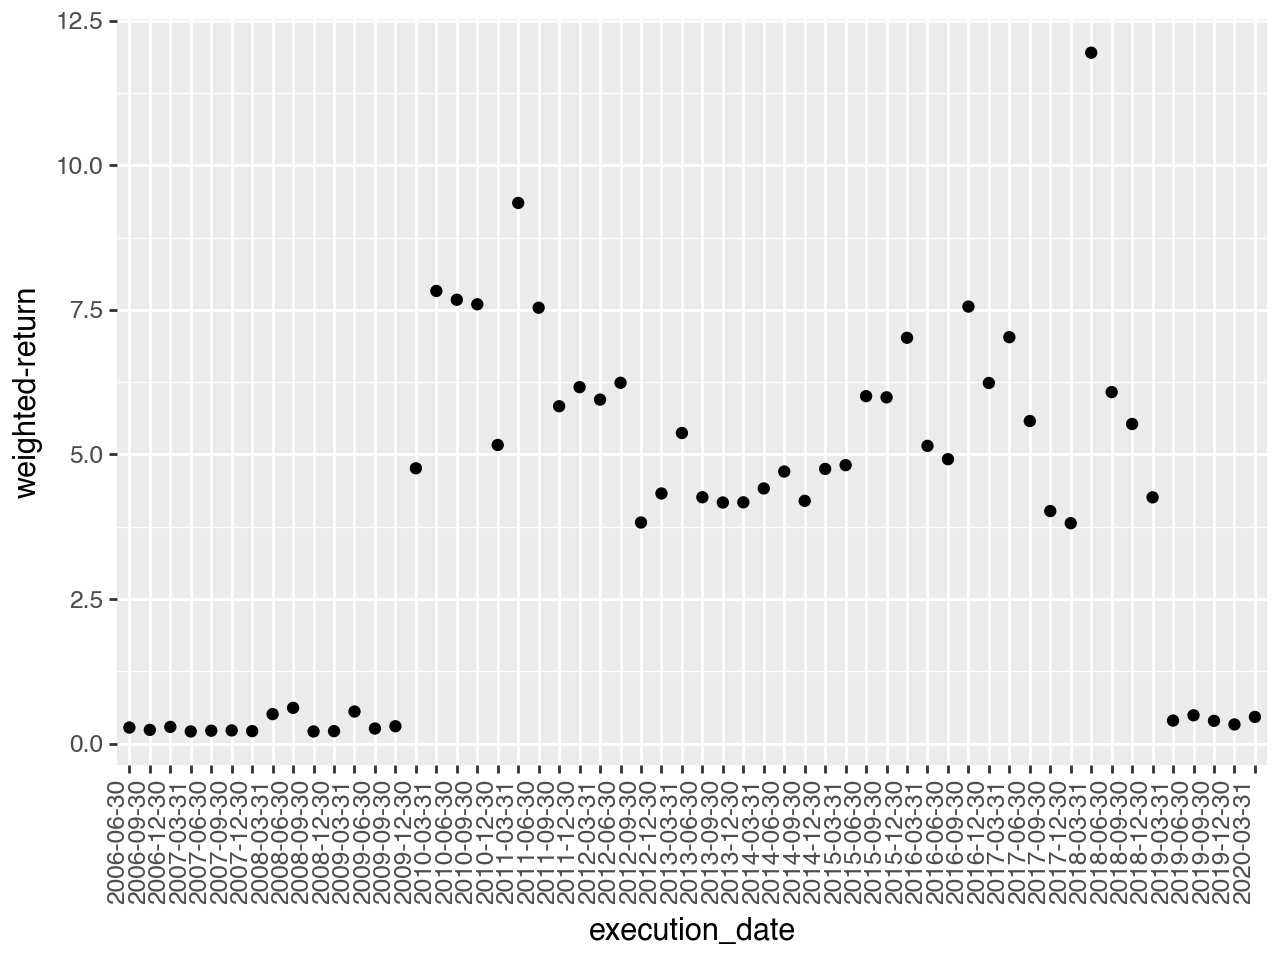

In [56]:
ggplot(train_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))


We have trained the first models for all the periods for you, but there are a lot of things which may be wrong or can be improved. Some ideas where you can start:
* Try to see if there is any kind of data leakage or suspicious features
* If the training part is very slow, try to see how you can modify it to execute faster tests
* Try to understand if the algorithm is learning correctly
* We are using a very high level metric to evaluate the algorithm so you maybe need to use some more low level ones
* Try to see if there is overfitting
* Try to see if there is a lot of noise between different trainings
* To simplify, why if you only keep the first tickers in terms of Market Cap?
* Change the number of quarters to train in the past


This function can be useful to compute the feature importance:

In [57]:
def draw_feature_importance(model,top = 15):
    fi = model.feature_importance()
    fn = model.feature_name()
    feature_importance = pd.DataFrame([{"feature":fn[i],"imp":fi[i]} for i in range(len(fi))])
    feature_importance = feature_importance.sort_values("imp",ascending = False).head(top)
    feature_importance = feature_importance.sort_values("imp",ascending = True)
    plot = ggplot(feature_importance,aes(x = "feature",y  = "imp")) + geom_col(fill = "lightblue") + coord_flip() +  scale_x_discrete(limits = feature_importance["feature"])
    return plot


In [58]:
from scipy.stats import lognorm
import matplotlib.pyplot as plt

## 1. Data leakage 
#!!!!!
Before trusting any result, we verify that the model is not trained on features containing future information. The baseline already removes obvious leaky columns (`stock_change_365`, `close_365`, etc.). Here we audit all remaining features and flag anything suspicious.

The naming convention in this dataset is:
- `__minus_N` — value N days **in the past** (safe to use)
- `_N` (no minus) — value N days **in the future** (leaky if kept)


In [59]:
# Original removal list
original_columns_to_remove = [
    "date", "improve_sp500", "Ticker", "freq", "set",
    "close_sp500_365", "close_365",
    "stock_change_365", "sp500_change_365",
    "stock_change_div_365",
    "stock_change_730", "sp500_change_365", "stock_change_div_730",
    "diff_ch_sp500", "diff_ch_avg_500",
    "execution_date", "target", "index", "quarter", "std_730", "count",
]

features_before_fix = [c for c in data_set.columns if c not in original_columns_to_remove]
suspicious = [
    f for f in features_before_fix
    if ("365" in f or "730" in f) and "__minus_" not in f
]

print("Leaky feature in original baseline:")
for f in suspicious:
    print(f"  {f}")

# After fix
features_after_fix = [c for c in data_set.columns if c not in get_columns_to_remove()]
suspicious_after = [
    f for f in features_after_fix
    if ("365" in f or "730" in f) and "__minus_" not in f
]
print(f"\nLeaky features after fix: {suspicious_after if suspicious_after else 'none'}")


Leaky feature in original baseline:
  sp500_change_730

Leaky features after fix: none


`sp500_change_730` is the SP500 return over the next 2 years. It is a future value from S&P500. We shouldn't have this data for the prediction part. `stock_change_730` was correctly excluded, but this one was missing. We fix it in `get_columns_to_remove()`, so all results are clean now.

## 2. Overfitting
We compare model's performance in train vs test to check if the model generalises or memorises.
- **`weighted-return`**: business metric. We get the 10 actions with higher predicted probability, and we calculate its real avg outcome in that year.
- **`binary_logloss`**: to measure how good the model assigns probabilities.

In [ ]:
test_final  = test_results.sort_values(["execution_date", "n_trees"]).drop_duplicates("execution_date", keep="last")
train_final = train_results.sort_values(["execution_date", "n_trees"]).drop_duplicates("execution_date", keep="last")

print(f"Mean train weighted-return: {train_final['weighted-return'].mean():.4f}")
print(f"Mean test  weighted-return: {test_final['weighted-return'].mean():.4f}")

# logloss: read last tree value per quarter directly from all_results
train_logloss = np.mean([all_results[d]['training']['binary_logloss'][-1] for d in all_results])
test_logloss  = np.mean([all_results[d]['valid_0']['binary_logloss'][-1] for d in all_results])

print(f"\nMean train logloss: {train_logloss:.4f}  (random baseline ≈ 0.693)")
print(f"Mean test  logloss: {test_logloss:.4f}  (random baseline ≈ 0.693)")


Mean train weighted-return: 3.9398
Mean test  weighted-return: 6.9797

Mean train logloss: 0.5844  (random baseline ≈ 0.693)
Mean test  logloss: 0.7046  (random baseline ≈ 0.693)


The weighted-return metric: the test looks better than the test, but the metric is picking 10 stocks out of around 2000 every quarter (very small sample). So some lucky samples such as post COVID can inflate the test average. Maybe the metric has too much variance, so maybe it's better to don't take conclusions from it. 

The binary_logloss: the reference point is 0.693 (model that always predicts 50% prob for any input).
The train logloss 0.584<0.693 tells the model has learnt something on train. It assigns probabilities better than randomly.
Test logloss of 0.705>0.693 says that on unseen data, the model is worse than randomly.

The conclusion is that there's overfitting: better than random on train and worse than random on test.
With only 40 trees and around 133 features, the model has limited capacity and fails to generalise.

## Step 3. Feature importance

After confirming overfitting, we see which features the model bases on. This tells us if the model is learning economically important signals or leaning on noise.

LightGBM's importance counts how many times each feature is used to split a tree node across all trees. Because we train one model per quarter, we average importance across all quarters to get a stable number.


In [63]:
fi_all = {}
for date, m in all_models.items():
    for feat, imp in zip(m.feature_name(), m.feature_importance()):
        fi_all[feat] = fi_all.get(feat, 0) + imp

fi_df = pd.DataFrame(list(fi_all.items()), columns=["feature", "importance"])
fi_df["importance"] = fi_df["importance"] / len(all_models)
fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)

print(f"Total features: {len(fi_df)}")
print(f"\nTop 20:")
print(fi_df.head(20).to_string(index=False))

zero_importance = fi_df[fi_df["importance"] == 0]
print(f"\nFeatures never used (importance = 0): {len(zero_importance)}")
print(zero_importance.to_string(index=False))


Total features: 133

Top 20:
                           feature  importance
                           close_0   91.178571
                     close_sp500_0   55.607143
           sp500_change__minus_730   40.125000
           sp500_change__minus_365   31.535714
                    std__minus_730   29.071429
           sp500_change__minus_120   28.178571
                                PB   23.892857
                    std__minus_120   22.946429
           stock_change__minus_365   22.875000
             DividendYieldLastYear   21.428571
                       GrossMargin   18.892857
         PropertyPlantAndEquipment   18.035714
                     AssetTurnover   18.017857
       stock_change_div__minus_730   17.839286
            Revenue_change_2_years   17.142857
           stock_change__minus_730   16.946429
RetainedEarningsAccumulatedDeficit   15.785714
                    std__minus_365   15.732143
                            EBITDA   14.964286
                         Revenu

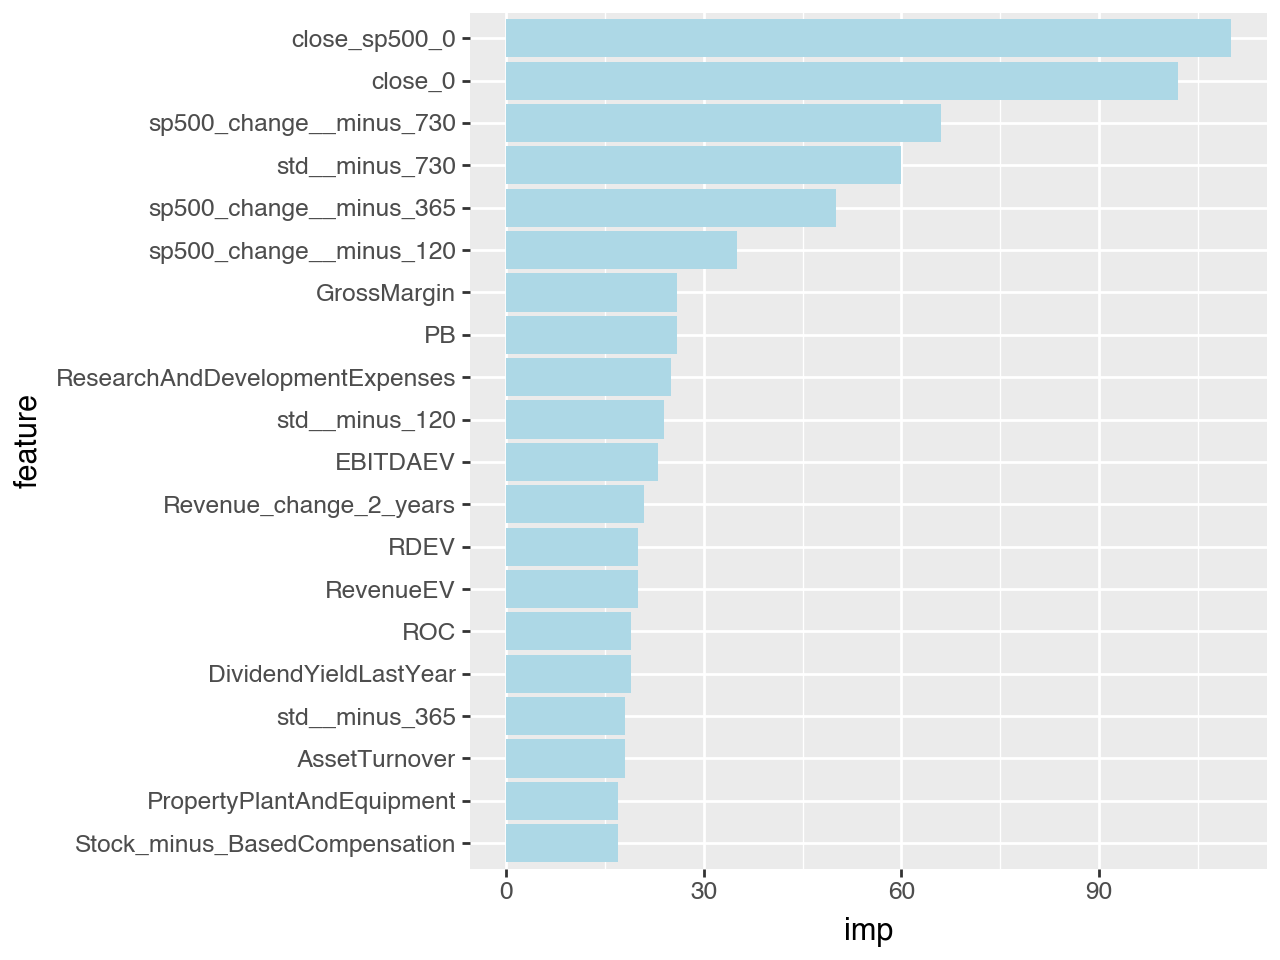

In [62]:
draw_feature_importance(all_models[sorted(all_models.keys())[-1]], top=20)


The top features by importance are:
1. close_0 (91) and close_sp500_0 (56): the current stock price and the current SP500 level. These are important but don't tell anything about the company.
2. SP500 momentum features: (sp500_change__minus_730, sp500_change__minus_365, sp500_change__minus_120). Again, give context about the market but not company-specific signal. The model is relying on market conditions.
3. std__minus_730, std__minus_120 is a company's historical price volatility. Higher volatility stocks have higher upside and downside, so this is a reasonable signal.
4. Financial features: PB, DividendYieldLastYear, GrossMargin, EBITDA, AssetTurnover. These are the features about the company we want the model to rely on and learn from them, but they rank lower than price and market features.

Only 1 feature has zero importance (EBITDAMargin), which means that the model uses almost everything it is given, but in none of the trained models, LightGBM has chosen EBITDAMargin as a split criteria. Maybe this is because its information is already covered by features as BITDA o GrossMargin.

## Step 4. Stability analysis

We will examine the results not just on average, but quarter by quarter. If the results on different quarters vary a lot, this indicates there's no consistence, the model is only is picking noise and not stable patterns.

We check two metrics per quarter:
- weighted-return: return of the top-10 portfolio vs SP500 
- logloss: accuracy of the predictions


In [65]:
per_quarter = pd.DataFrame([{
    "execution_date": str(d),
    "logloss": all_results[d]["valid_0"]["binary_logloss"][-1],
    "weighted_return": all_results[d]["valid_0"]["weighted-return"][-1],
} for d in all_results])

wr = per_quarter["weighted_return"]
ll = per_quarter["logloss"]

print(f"weighted-return:  mean={wr.mean():.3f}  std={wr.std():.3f}  min={wr.min():.3f}  max={wr.max():.3f}")
print(f"logloss:          mean={ll.mean():.4f}  std={ll.std():.4f}  min={ll.min():.4f}  max={ll.max():.4f}")
print(f"\nQuarters with weighted-return > 0: {(wr > 0).sum()}/{len(per_quarter)}")
print(f"Quarters with logloss < 0.693 (better than random): {(ll < 0.693).sum()}/{len(per_quarter)}")

print("\nTop 5 quarters by weighted-return (outlier check):")
print(per_quarter.sort_values('weighted_return', ascending=False).head(5).to_string(index=False))

print("\nAll quarters sorted by date (weighted_return):")
print(per_quarter.sort_values('execution_date')[['execution_date','weighted_return','logloss']].to_string(index=False))


weighted-return:  mean=6.980  std=25.127  min=-0.170  max=122.103
logloss:          mean=0.7046  std=0.0429  min=0.6078  max=0.8414

Quarters with weighted-return > 0: 41/56
Quarters with logloss < 0.693 (better than random): 25/56

Top 5 quarters by weighted-return (outlier check):
               execution_date  logloss  weighted_return
2014-12-30T00:00:00.000000000 0.709723       122.102985
2014-06-30T00:00:00.000000000 0.681525        92.076531
2014-09-30T00:00:00.000000000 0.711386        91.910240
2014-03-31T00:00:00.000000000 0.687197        74.911531
2010-03-31T00:00:00.000000000 0.724097         1.051294

All quarters sorted by date (weighted_return):
               execution_date  weighted_return  logloss
2006-06-30T00:00:00.000000000         0.099404 0.759610
2006-09-30T00:00:00.000000000         0.035528 0.730303
2006-12-30T00:00:00.000000000        -0.052195 0.715078
2007-03-31T00:00:00.000000000        -0.067471 0.710833
2007-06-30T00:00:00.000000000        -0.045395 0.711

The weighted-return has a mean of 6.98 but a standard deviation of 25.13. The std is much higher than the mean, which is unstable. The problem might be that four consecutive quarters in 2014 recorded returns of 74, 91, 92 and 122. These outliers inflate the overall average.

The logloss is more trustable: only 25 out of 56 quarters achieve a logloss below the random baseline of 0.693. In more than half of all quarters the model predicts worse than random guessing.

The model is highly unstable. Its average performance is not driven by a consistent predictive ability. After overfitting (Step 2) and feature importance (Step 3): the model is not learning generalisable patterns.

## Step 5. Market Cap filter

One hypothesis for the instability is that the model is trying to predict across a very heterogeneous field of the stock market. There's tiny micro-cap stocks with untrustable financial data, and  financials to large companies with stable data. Small stocks are noisier, their financial data is less consistent and their prices more erratic.

The dataset has a Market_cap column. We compare 3 scenarios: all stocks (baseline), the top-500 and top-300 companies by market cap.


In [66]:
def run_experiment(top_market_cap=None):
    global train_set, test_set
    results = {}
    for execution_date in np.sort(data_set['execution_date'].unique()):
        train_set, test_set = split_train_test_by_period(data_set, execution_date)
        if top_market_cap is not None:
            test_set = test_set.nlargest(top_market_cap, 'Market_cap')
        if len(train_set) > 0 and len(test_set) > 0:
            model, evals_result, _, _ = train_model(train_set, test_set, n_estimators=n_trees)
            results[execution_date] = evals_result
    return results

def summarise(results, label):
    ll = [results[d]['valid_0']['binary_logloss'][-1] for d in results]
    wr = [results[d]['valid_0']['weighted-return'][-1] for d in results]
    print(f"{label}:")
    print(f"  logloss  mean={np.mean(ll):.4f}  std={np.std(ll):.4f}  quarters < 0.693: {sum(l < 0.693 for l in ll)}/{len(ll)}")
    print(f"  w-return mean={np.mean(wr):.3f}   std={np.std(wr):.3f}")

results_all = run_experiment(top_market_cap=None)
results_500 = run_experiment(top_market_cap=500)
results_300 = run_experiment(top_market_cap=300)

summarise(results_all, "Baseline (all tickers)")
summarise(results_500, "Top-500 Market Cap")
summarise(results_300, "Top-300 Market Cap")


Baseline (all tickers):
  logloss  mean=0.7046  std=0.0425  quarters < 0.693: 25/56
  w-return mean=6.980   std=24.901
Top-500 Market Cap:
  logloss  mean=0.7090  std=0.0384  quarters < 0.693: 16/56
  w-return mean=0.071   std=0.088
Top-300 Market Cap:
  logloss  mean=0.7135  std=0.0434  quarters < 0.693: 16/56
  w-return mean=0.039   std=0.071


Filtering to large-cap stocks eliminates extreme volatility from weighted-return (std from 24.9 to 0.088), which confirms that the baseline's high average was almost entirely based on a few lucky small quarters. However, the logloss gets worse as we filter (0.705 to 0.709 to 0.714), and less quarters beat the random baseline (25 to 16).

This is an important trade-off: large-cap stocks are more stable but also harder to predict. They are the most followed companies in the market. The model loses luck from small-cap outliers, and ends with a more real but worse result. Filtering by Market Cap does not improve the model, it just removes the noise that was inflating the performance.


## Step 6. Training window size
The question to solve is: how many quarters should we use to train? Actually, baseline uses n_train_quarters=36 (9 years of history). The hypothesis is that financial patterns change over time, so training on too much history might introduce signals from market regimes. We test the windows of 8, 12, 20 and 36 quarters to find the best trade-off.


In [67]:
def run_nquarters_experiment(n_q):
    global train_set, test_set
    results = {}
    for execution_date in np.sort(data_set['execution_date'].unique()):
        train_set = data_set.loc[data_set['execution_date'] <= pd.to_datetime(execution_date) - pd.Timedelta(350, unit='day')]
        train_set = train_set[~pd.isna(train_set['diff_ch_sp500'])]
        dates = train_set.sort_values('execution_date')['execution_date'].unique()
        train_set = train_set[train_set['execution_date'].isin(dates[-n_q:])]
        test_set = data_set.loc[data_set['execution_date'] == execution_date]
        test_set = test_set[~pd.isna(test_set['diff_ch_sp500'])]
        test_set = test_set.sort_values('date', ascending=False).drop_duplicates('Ticker', keep='first')
        if len(train_set) > 0 and len(test_set) > 0:
            results[execution_date] = train_model(train_set, test_set, n_estimators=n_trees)[1]
    return results

for n_q in [8, 12, 20, 36]:
    r = run_nquarters_experiment(n_q)
    ll = [r[d]['valid_0']['binary_logloss'][-1] for d in r]
    wr = [r[d]['valid_0']['weighted-return'][-1] for d in r]
    print(f"n_train_quarters={n_q:2d}: logloss={np.mean(ll):.4f} (std={np.std(ll):.4f})  "
          f"w-return={np.mean(wr):.3f} (std={np.std(wr):.3f})  "
          f"quarters<0.693: {sum(l<0.693 for l in ll)}/{len(ll)}")


n_train_quarters= 8: logloss=0.7242 (std=0.0484)  w-return=0.250 (std=0.969)  quarters<0.693: 10/56
n_train_quarters=12: logloss=0.7133 (std=0.0449)  w-return=0.191 (std=0.541)  quarters<0.693: 17/56
n_train_quarters=20: logloss=0.7102 (std=0.0418)  w-return=3.483 (std=17.120)  quarters<0.693: 18/56
n_train_quarters=36: logloss=0.7046 (std=0.0425)  w-return=6.980 (std=24.901)  quarters<0.693: 25/56


**Interpretation:**
In conclusion, more history is better. We expected data from past 9 years were past noise, but the result is the opposite, the logloss improves when we have more historical data. So the problem is not that we are training with stale data, is that the model needs more examples to find signal. 

The baseline choice of 36 quarters is the best among these options.

## Step 7. Conclusions

We tried to improve the baseline LightGBM model for equity portfolio selection. 

### What we fixed
**Step 1. Data leakage:** The baseline included sp500_change_730 (2 year future SP500 return) as a training feature. This is information that does not exist at prediction time and was removed. All next results are computed on the clean dataset.

### What we concluded

**Step 2. Overfitting:** Train logloss (0.584) is better than random, but test logloss (0.705) is worse than random (baseline = 0.693). The model memorises training patterns that do not generalise to new quarters.

**Step 3. Feature importance:** The model relies primarily on market features (close_0, close_sp500_0, SP500 momentum) rather than company fundamentals. It is making a bet on market conditions, not in stock picking. Only 1 feature (EBITDAMargin) was never used across all training runs.

**Step 4. Stability:** The `weighted-return` has a mean of 6.98 but a standard deviation of 25.13 — driven by three outlier quarters in 2014 with returns of 74, 92 and 122. Only 25 of 56 quarters (45%) beat the random logloss baseline. The model is not consistently useful.


### What we tried to improve

**Step 5. Market cap filter:** Restricting the test to the top-500 or top-300 companies by market cap removed the high variance in weighted-return (std goes from 24.9 to 0.088), confirming that the baseline's high average was noise from small cap outliers. However, logloss worsened (0.705 to 0.714) and fewer quarters beat random (25 to 16). Large cap stocks are more efficiently priced and harder to predict. Not an improvement.

**Step 6. Training window:** Using fewer quarters of history (8, 12, 20, 36) consistently produced worse logloss. The model benefits from more training data, the problem is not stale historical patterns but lack of predictive signal. The baseline choice of 36 quarters is already optimal among the options. No improvement found.

### Overall assessment
Despite the fixes and analysis, the model does not reliably outperform random guessing on new data. The main difficulty is: financial markets are very efficient, and the signal connecting quarterly company fundamentals to 1 year stock outperformance is weak and unstable across market.

The most productive next directions would be:
- **Better features**: analyst estimates, sentiment data, inside trading signals, sector normalisation of fundamentals.
- **Different target**: instead of binary outperform/underperform, predicting the continuous diff_ch_sp500 as a regression might provide more training signal.
- **Ensemble across regimes**: training separate models for bull/bear/neutral market periods rather than a single model across all regimes.
